In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Sample data
data = {
    'text': [
        "I love this product. It's amazing!",
        "This is terrible. I hate it.",
        "It's not bad, but I expected more.",
        "This is great, I'm satisfied.",
        "I'm not happy with the quality."
    ],
    'sentiment': ['positive', 'negative', 'neutral', 'positive', 'negative']
}

df = pd.DataFrame(data)

# Preprocessing
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])

# Train a simple model (e.g., Naive Bayes)
model = MultinomialNB()
model.fit(X, df['sentiment'])

# Predictions and accuracy
predictions = model.predict(X)
accuracy = accuracy_score(df['sentiment'], predictions)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 1.00


In [ ]:
# Explainability using feature importance
feature_names = vectorizer.get_feature_names_out()
top_words_positive = [feature_names[i] for i in model.feature_log_prob_[1].argsort()[-5:][::-1]]
top_words_negative = [feature_names[i] for i in model.feature_log_prob_[0].argsort()[-5:][::-1]]

print("Top words for positive sentiment:", top_words_positive)
print("Top words for negative sentiment:", top_words_negative)

Top words for positive sentiment: ['bad', 'but', 'expected', 'not', 'more']
Top words for negative sentiment: ['with', 'the', 'terrible', 'quality', 'not']


In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 5.4 MB/s eta 0:00:00


Model Accuracy: 1.00


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


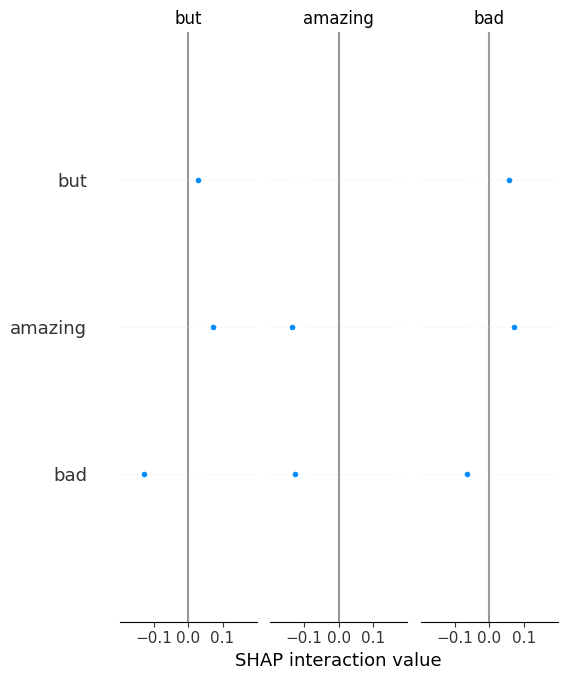

In [ ]:
import pandas as pd
import shap
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Sample data
data = {
    'text': [
        "I love this product. It's amazing!",
        "This is terrible. I hate it.",
        "It's not bad, but I expected more.",
        "This is great, I'm satisfied.",
        "I'm not happy with the quality."
    ],
    'sentiment': ['positive', 'negative', 'neutral', 'positive', 'negative']
}

df = pd.DataFrame(data)

# Preprocessing
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])

# Train a simple model (e.g., Logistic Regression)
model = LogisticRegression()
model.fit(X, df['sentiment'])

# Predictions and accuracy
predictions = model.predict(X)
accuracy = accuracy_score(df['sentiment'], predictions)
print(f"Model Accuracy: {accuracy:.2f}")

# Initialize SHAP explainer
explainer = shap.Explainer(model, X, feature_names=vectorizer.get_feature_names_out())

# Choose a sample instance for explanation
sample_idx = 0  # Choose the index of the sample to explain
sample_text = df['text'][sample_idx]
sample_vector = X[sample_idx].toarray()  # Convert sparse matrix to dense array

# Explain the prediction using SHAP values
shap_values = explainer(sample_vector)

# Display SHAP values
shap.summary_plot(shap_values, feature_names=vectorizer.get_feature_names_out(), plot_type="bar", show=False)
